In [335]:
from astropy.io import fits
import numpy as np
from matplotlib import pyplot as plt
from glob import glob
import seaborn as sns
from scipy import stats
import matplotlib.mlab as mlab
from scipy.signal import find_peaks
from scipy.optimize import curve_fit

%matplotlib inline
sns.set()

# bias

In [336]:
image = fits.open('biases_030bias.fit')
image[0].data
print(np.min(image[0].data), np.max(image[0].data))

182 352


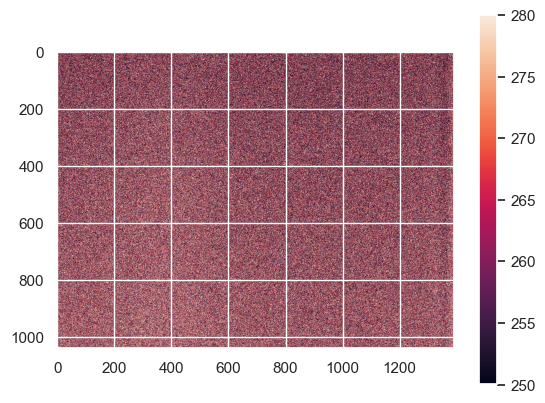

In [337]:
pixelval = image[0].data
plt.imshow(pixelval, vmin=250 ,vmax=280)
plt.colorbar()

In [338]:
biases = glob('biases*')
print(biases)

['biases_031bias.fit', 'biases_038bias.fit', 'biases_039bias.fit', 'biases_030bias.fit', 'biases_032bias.fit', 'biases_033bias.fit', 'biases_036bias.fit', 'biases_037bias.fit', 'biases_035bias.fit', 'biases_034bias.fit']


In [339]:
bias_data = np.stack([fits.getdata(f).astype(float) for f in biases], axis=0)

master_bias = np.mean(bias_data, axis=0)

263.6975490036665 5.5433156610801895
0.9999907053608893


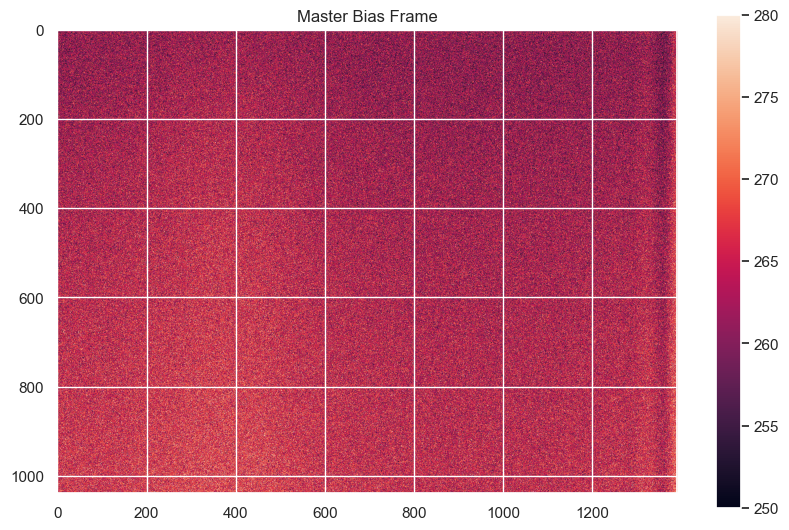

In [386]:
plt.figure(figsize=(10,8))
plt.imshow(master_bias, vmin=250, vmax=280)
#plt.scatter(900,500)
plt.colorbar(shrink=0.8)
plt.title('Master Bias Frame')

print(np.mean(master_bias), np.std(master_bias))

master_bias = master_bias / 263.70
print(np.mean(master_bias))

In [341]:
mean_box = master_bias[800:1000, 400:600].mean()
std_box = master_bias[800:1000, 400:600].std()

print(f'mean: {mean_box}\nstd: {std_box}')

mean: 266.46279749999997
std: 5.365270796893084


# flat

In [342]:
imagef = fits.open('flats_001flat.fit')
imagef[0].data
print(np.min(imagef[0].data), np.max(imagef[0].data))

320 27111


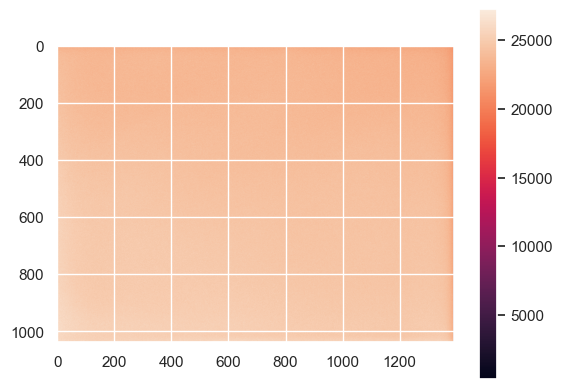

In [343]:
pixelvalf = imagef[0].data
plt.imshow(pixelvalf, vmin=320 ,vmax=27250)
plt.colorbar()

In [344]:
flats = glob('flats_*')
print(flats)

['flats_008flat.fit', 'flats_001flat.fit', 'flats_010flat.fit', 'flats_009flat.fit', 'flats_002flat.fit', 'flats_003flat.fit', 'flats_006flat.fit', 'flats_007flat.fit', 'flats_005flat.fit', 'flats_004flat.fit']


In [345]:
flat_data = []
for f in flats:
    dataf = fits.getdata(f).astype(float)
    datafb = dataf - master_bias
    flat_data.append(datafb)

flat_data = np.stack(flat_data, axis=0)
master_flat = np.mean(flat_data, axis=0)

24027.38192069325 907.408904417156
1.0000000799376898


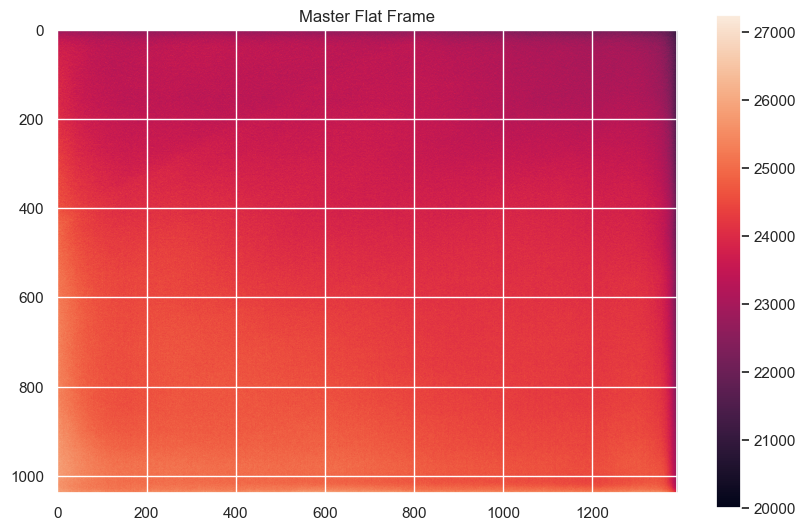

In [346]:
plt.figure(figsize=(10,8))
plt.imshow(master_flat, vmin=20000, vmax=27250)
#plt.scatter(900,500)
plt.colorbar(shrink=0.8)
plt.title('Master Flat Frame')

print(np.mean(master_flat), np.std(master_flat))

master_flat = master_flat / 24027.38
print(np.mean(master_flat))

In [347]:
mean_boxf = master_flat[800:1000, 400:600].mean()
std_boxf = master_flat[800:1000, 400:600].std()

print(f'mean: {mean_boxf}\nstd: {std_boxf}')

mean: 1.0321517471942427
std: 0.007674310620867742


# readnoise and gain

## indiv. readnoise/gain

In [348]:
print(biases)
print(flats)

['biases_031bias.fit', 'biases_038bias.fit', 'biases_039bias.fit', 'biases_030bias.fit', 'biases_032bias.fit', 'biases_033bias.fit', 'biases_036bias.fit', 'biases_037bias.fit', 'biases_035bias.fit', 'biases_034bias.fit']
['flats_008flat.fit', 'flats_001flat.fit', 'flats_010flat.fit', 'flats_009flat.fit', 'flats_002flat.fit', 'flats_003flat.fit', 'flats_006flat.fit', 'flats_007flat.fit', 'flats_005flat.fit', 'flats_004flat.fit']


In [349]:
bias_data = []
for f in biases:
    data_b = fits.getdata(f).astype(float)
    bias_data.append(data_b)

flat_data = []
for f in flats:
    dataf = fits.getdata(f).astype(float)
    datafb = dataf - master_bias
    flat_data.append(datafb)
    
biases = bias_data
flats = flat_data

In [350]:
biasdif1 = biases[0] - biases[1]
flatdif1 = flats[0] - flats[1]

mean_bias1 = np.mean(biases[0]) + np.mean(biases[1])
mean_flat1 = np.mean(flats[0]) + np.mean(flats[1])

std_bias1 = np.std(biasdif1)
std_flat1 = np.std(flatdif1)

gain1 = (mean_flat1 - mean_bias1) / (std_flat1**2 - std_bias1**2)
readnoise1 = gain1 * (std_bias1) / (np.sqrt(2))

print(f'gain = {gain1}\nreadnoise = {readnoise1}')

gain = 0.2696555886000731
readnoise = 4.470695042713425


In [351]:
biasdif2 = biases[2] - biases[3]
flatdif2 = flats[2] - flats[3]

mean_bias2 = np.mean(biases[2]) + np.mean(biases[3])
mean_flat2 = np.mean(flats[2]) + np.mean(flats[3])

std_bias2 = np.std(biasdif2)
std_flat2 = np.std(flatdif2)

gain2 = (mean_flat2 - mean_bias2) / (std_flat2**2 - std_bias2**2)
readnoise2 = gain2 * (std_bias2) / (np.sqrt(2))

print(f'gain = {gain2}\nreadnoise = {readnoise2}')

gain = 0.26984208637440976
readnoise = 4.471747003084644


In [352]:
biasdif3 = biases[4] - biases[5]
flatdif3 = flats[4] - flats[5]

mean_bias3 = np.mean(biases[4]) + np.mean(biases[5])
mean_flat3 = np.mean(flats[4]) + np.mean(flats[5])

std_bias3 = np.std(biasdif3)
std_flat3 = np.std(flatdif3)

gain3 = (mean_flat3 - mean_bias3) / (std_flat3**2 - std_bias3**2)
readnoise3 = gain3 * (std_bias3) / (np.sqrt(2))

print(f'gain = {gain3}\nreadnoise = {readnoise3}')

gain = 0.26997617880249297
readnoise = 4.467316109555829


In [353]:
biasdif4 = biases[6] - biases[7]
flatdif4 = flats[6] - flats[7]

mean_bias4 = np.mean(biases[6]) + np.mean(biases[7])
mean_flat4 = np.mean(flats[6]) + np.mean(flats[7])

std_bias4 = np.std(biasdif4)
std_flat4 = np.std(flatdif4)

gain4 = (mean_flat4 - mean_bias4) / (std_flat4**2 - std_bias4**2)
readnoise4 = gain4 * (std_bias4) / (np.sqrt(2))

print(f'gain = {gain4}\nreadnoise = {readnoise4}')

gain = 0.2703136343422885
readnoise = 4.479188725747097


In [354]:
biasdif5 = biases[8] - biases[9]
flatdif5 = flats[8] - flats[9]

mean_bias5 = np.mean(biases[8]) + np.mean(biases[9])
mean_flat5 = np.mean(flats[8]) + np.mean(flats[9])

std_bias5 = np.std(biasdif5)
std_flat5 = np.std(flatdif5)

gain5 = (mean_flat5 - mean_bias5) / (std_flat5**2 - std_bias5**2)
readnoise5 = gain5 * (std_bias5) / (np.sqrt(2))

print(f'gain = {gain5}\nreadnoise = {readnoise5}')

gain = 0.27018172333707086
readnoise = 4.472157177618272


## ALL readnoise/gain

In [355]:
all_gains = []
all_readnoises = []

for i in range(0, len(biases), 2):
    bias_dif = biases[i] - biases[i+1]
    flat_dif = flats[i] - flats[i+1]

    mean_bias = np.mean(biases[i]) + np.mean(biases[i+1])
    mean_flat = np.mean(flats[i]) + np.mean(flats[i+1])

    std_bias = np.std(bias_dif)
    std_flat = np.std(flat_dif)

    gain = (mean_flat - mean_bias) / (std_flat**2 - std_bias**2)
    readnoise = gain * std_bias / np.sqrt(2)

    all_gains.append(gain)
    all_readnoises.append(readnoise)

    print(f'Pair {i//2 + 1}:\ngain = {gain}\nreadnoise = {readnoise}')

avg_gain = np.mean(all_gains)
avg_readnoise = np.mean(all_readnoises)
print(f"\nAverage Gain: {avg_gain:.4f}")
print(f"Average Readnoise: {avg_readnoise:.4f}")

Pair 1:
gain = 0.2696555886000731
readnoise = 4.470695042713425
Pair 2:
gain = 0.26984208637440976
readnoise = 4.471747003084644
Pair 3:
gain = 0.26997617880249297
readnoise = 4.467316109555829
Pair 4:
gain = 0.2703136343422885
readnoise = 4.479188725747097
Pair 5:
gain = 0.27018172333707086
readnoise = 4.472157177618272

Average Gain: 0.2700
Average Readnoise: 4.4722


# plotting loop for lamps

In [356]:
def plot_image_grid(file_list, title_prefix="Image"):
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    axes = axes.flatten()  # single index for iteration

    for i, file in enumerate(file_list):
        if i >= 10: break # Stop if there are more than 10 files
        
        data = fits.getdata(file)
        
        im = axes[i].imshow(data, vmin=np.percentile(data, 1), vmax=np.percentile(data, 99))
        axes[i].set_title(f"{title_prefix} {i}: {file}")
        axes[i].axis('off')
        axes[i].grid(False) # this and axis removed for cleaner look
        
    plt.tight_layout()
    plt.show()

# Mercury

In [357]:
imagem = fits.open('mercury_132mercury.fit')
imagem[0].data
print(np.min(imagem[0].data), np.max(imagem[0].data))

0 65535


In [358]:
mercury = sorted(glob('mercury_*'))
print(mercury)

['mercury_125mercury.fit', 'mercury_126mercury.fit', 'mercury_127mercury.fit', 'mercury_128mercury.fit', 'mercury_129mercury.fit', 'mercury_130mercury.fit', 'mercury_131mercury.fit', 'mercury_132mercury.fit', 'mercury_133mercury.fit', 'mercury_134mercury.fit']


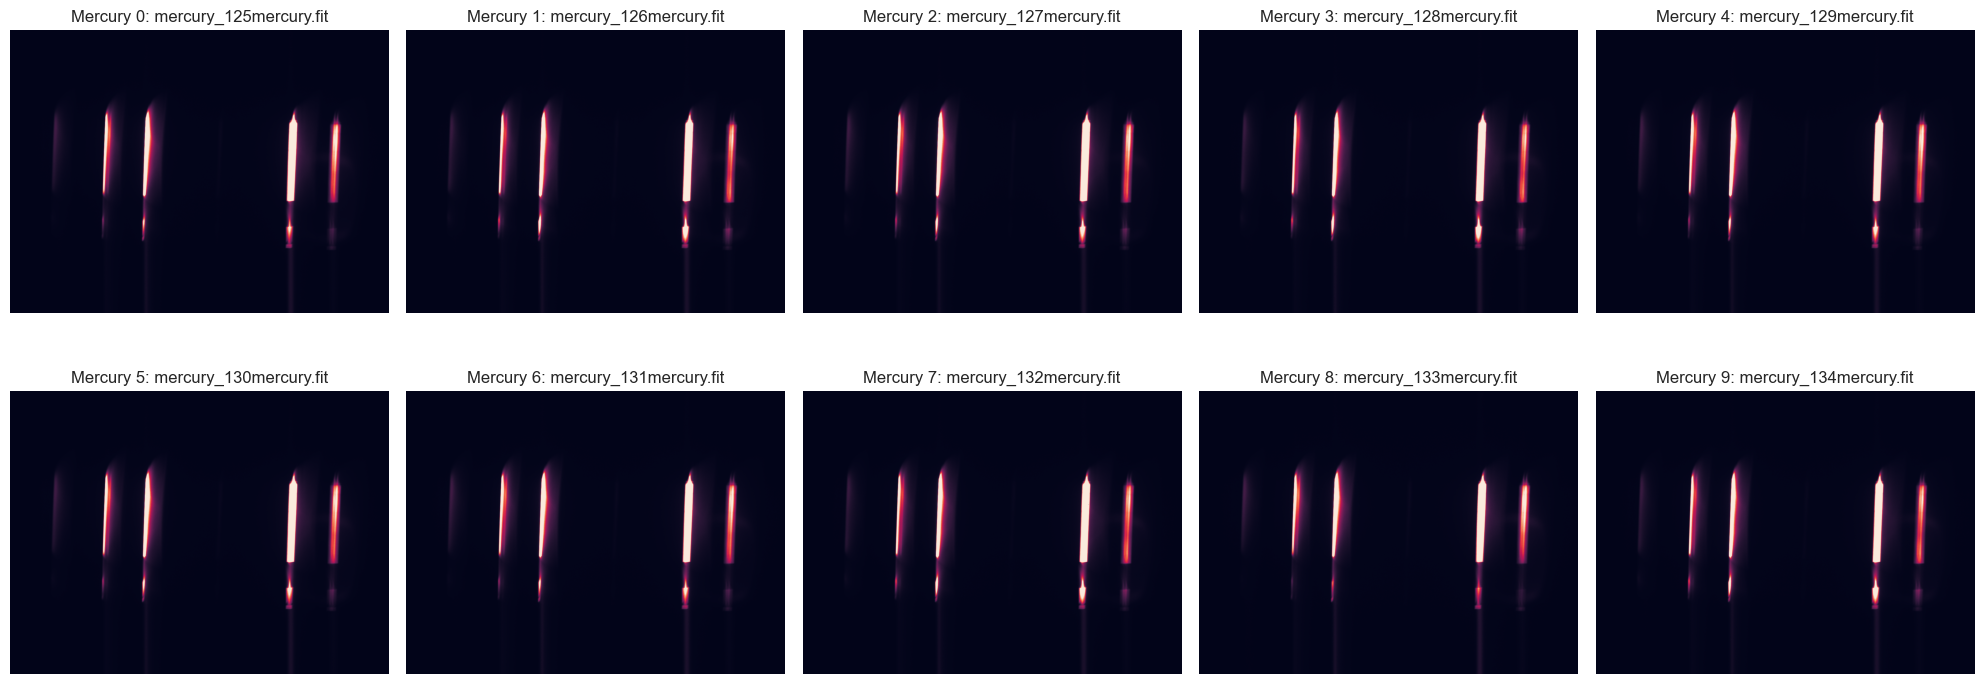

In [359]:
plot_image_grid(mercury, title_prefix="Mercury")

In [360]:
for i in range(len(mercury)):
    print(f"Image {i}\nmin: {np.min(fits.getdata(mercury[i]))}, max: {np.max(fits.getdata(mercury[i]))}")

Image 0
min: 217, max: 65535
Image 1
min: 215, max: 65535
Image 2
min: 214, max: 65535
Image 3
min: 215, max: 65535
Image 4
min: 216, max: 65535
Image 5
min: 208, max: 65535
Image 6
min: 217, max: 65535
Image 7
min: 0, max: 65535
Image 8
min: 218, max: 65535
Image 9
min: 211, max: 65535


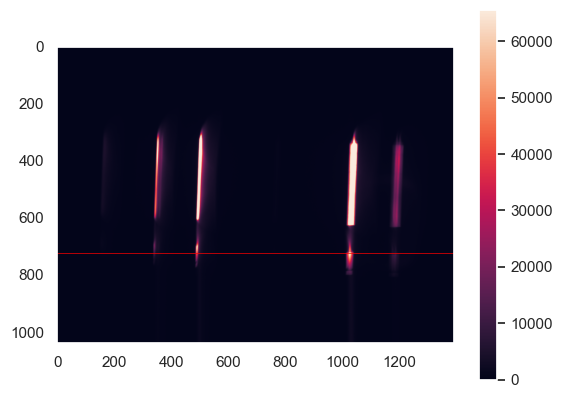

(1039, 1391)


In [361]:
# Chose image 7 as the best exposure

imagem = fits.open('mercury_132mercury.fit')
merc = imagem[0].data

plt.imshow(merc, vmin=0, vmax=65535)
plt.axhline(y=725, color='red', linewidth=0.5)
plt.colorbar()
plt.grid(False)

plt.show()

print(merc.shape)

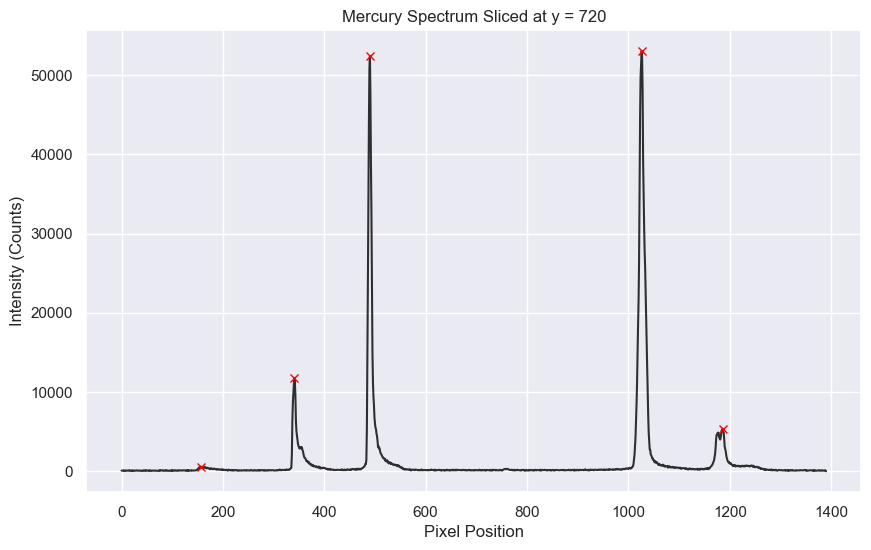

Peak X-positions (pixels): [ 157  341  490 1026 1186]
Peak 1: x = 157, Intensity = 577.2
Peak 2: x = 341, Intensity = 11767.5
Peak 3: x = 490, Intensity = 52428.5
Peak 4: x = 1026, Intensity = 53010.9
Peak 5: x = 1186, Intensity = 5382.2


In [362]:
clean_merc = merc - master_bias

spec_slice_m = clean_merc[720, :]
peaks, properties = find_peaks(spec_slice_m, prominence=500, distance=10)

plt.figure(figsize=(10, 6))
plt.plot(spec_slice_m, color='black', alpha=0.8)
plt.plot(peaks, spec_slice_m[peaks], "x", color='red')

plt.title("Mercury Spectrum Sliced at y = 720")
plt.xlabel("Pixel Position")
plt.ylabel("Intensity (Counts)")

plt.show()

print(f"Peak X-positions (pixels): {peaks}")
for i, p in enumerate(peaks):
    print(f"Peak {i+1}: x = {p}, Intensity = {spec_slice_m[p]:.1f}")

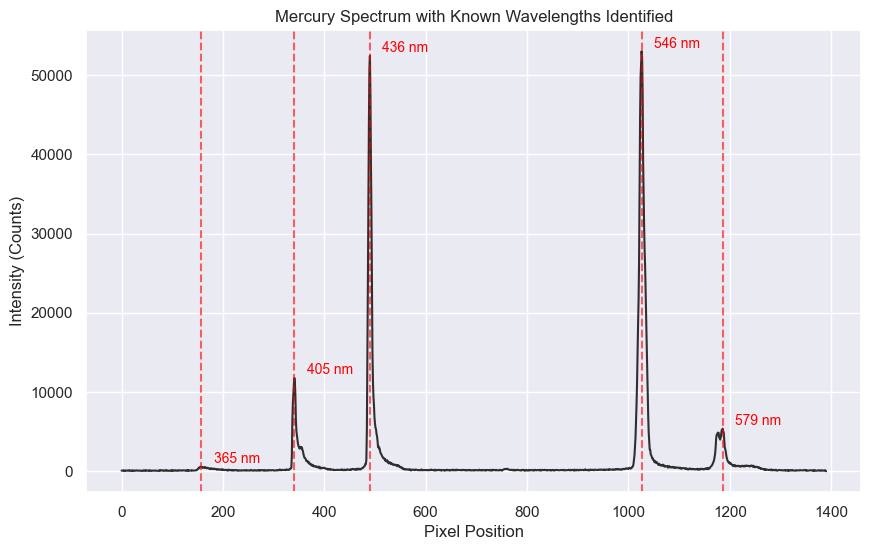

In [363]:
pixel_peaks = [157, 341, 490, 1026, 1186]
wavelength_labels = ["365 nm", "405 nm", "436 nm", "546 nm", "579 nm"]

plt.figure(figsize=(10, 6))
plt.plot(spec_slice_m, color='black', alpha=0.8)

for px, label in zip(pixel_peaks, wavelength_labels):
    plt.axvline(x=px, color='red', linestyle='--', alpha=0.6)
    plt.text(px + 70, spec_slice_m[px] + 100, label, 
             verticalalignment='bottom', horizontalalignment='center', color='red', size=10)

plt.title("Mercury Spectrum with Known Wavelengths Identified")
plt.xlabel("Pixel Position")
plt.ylabel("Intensity (Counts)")
plt.show()

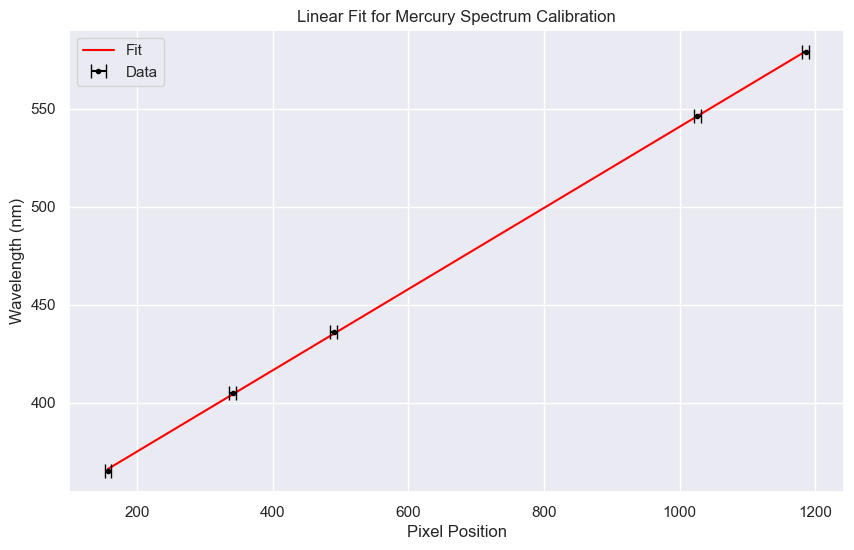

Slope = 0.2071, Intercept = 333.6445
Mercury Calibration Margin of Error: 0.7399 nm


In [390]:
x = np.array([157, 341, 490, 1026, 1186])
y = np.array([365, 405, 436, 546, 579])

merc_fit = np.polyfit(x, y, 1)
m, c = merc_fit

y_merc_fit = m * x + c
err = y - y_merc_fit
merc_err = np.std(err)

plt.figure(figsize=(10, 6))
plt.errorbar(x, y, xerr=5, fmt='.', capsize=5, label='Data', color='black', zorder=2)
plt.plot(x, y_merc_fit, label='Fit', color='red', zorder=1)

plt.ylabel('Wavelength (nm)')
plt.xlabel('Pixel Position')
plt.title('Linear Fit for Mercury Spectrum Calibration')
plt.legend()

plt.show()

print(f"Slope = {m:.4f}, Intercept = {c:.4f}")
print(f"Mercury Calibration Margin of Error: {merc_err:.4f} nm")

### Saturated Slice (for discussion)

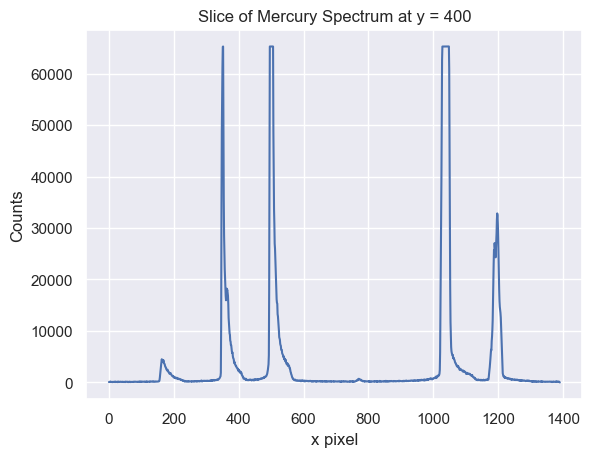

In [365]:
plt.plot(clean_merc[400, :])
plt.title("Slice of Mercury Spectrum at y = 400")

plt.xlabel("x pixel")
plt.ylabel("Counts")

plt.show()

Peak X-positions (pixels): [ 163  352  503  769 1032 1197]
Peak 1: x = 163, Intensity = 4503.6
Peak 2: x = 352, Intensity = 65268.9
Peak 3: x = 503, Intensity = 65276.5
Peak 4: x = 769, Intensity = 693.2
Peak 5: x = 1032, Intensity = 65281.2
Peak 6: x = 1197, Intensity = 32836.4


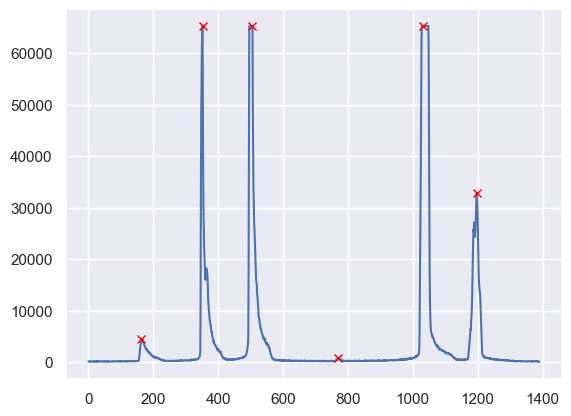

In [366]:
spec_slice = clean_merc[400, :]
peaks, properties = find_peaks(spec_slice, prominence=500, distance=15)

plt.plot(spec_slice)
plt.plot(peaks, spec_slice[peaks], "x", color='red')

# 4. Print the X-positions (pixel indices)
print(f"Peak X-positions (pixels): {peaks}")
for i, p in enumerate(peaks):
    print(f"Peak {i+1}: x = {p}, Intensity = {spec_slice[p]:.1f}")

plt.show()

# Sodium

189 42236


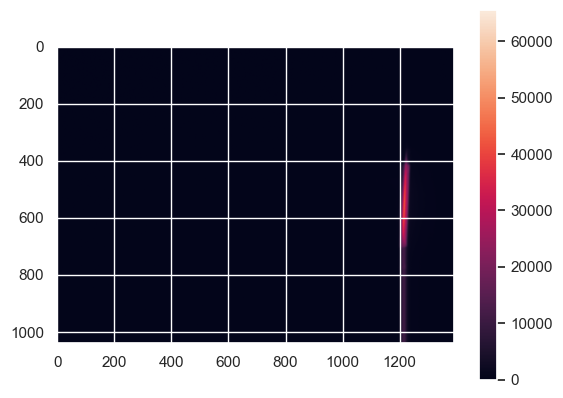

In [367]:
images = fits.open('sodium_009sodium.fit')
images[0].data
print(np.min(images[0].data), np.max(images[0].data))

sod = images[0].data
plt.imshow(sod, vmin=0 ,vmax=65535)
plt.colorbar()

In [368]:
sodium = sorted(glob('*sodium.fit'))
print(sodium)

['sodium_000sodium.fit', 'sodium_001sodium.fit', 'sodium_002sodium.fit', 'sodium_003sodium.fit', 'sodium_004sodium.fit', 'sodium_005sodium.fit', 'sodium_006sodium.fit', 'sodium_007sodium.fit', 'sodium_008sodium.fit', 'sodium_009sodium.fit']


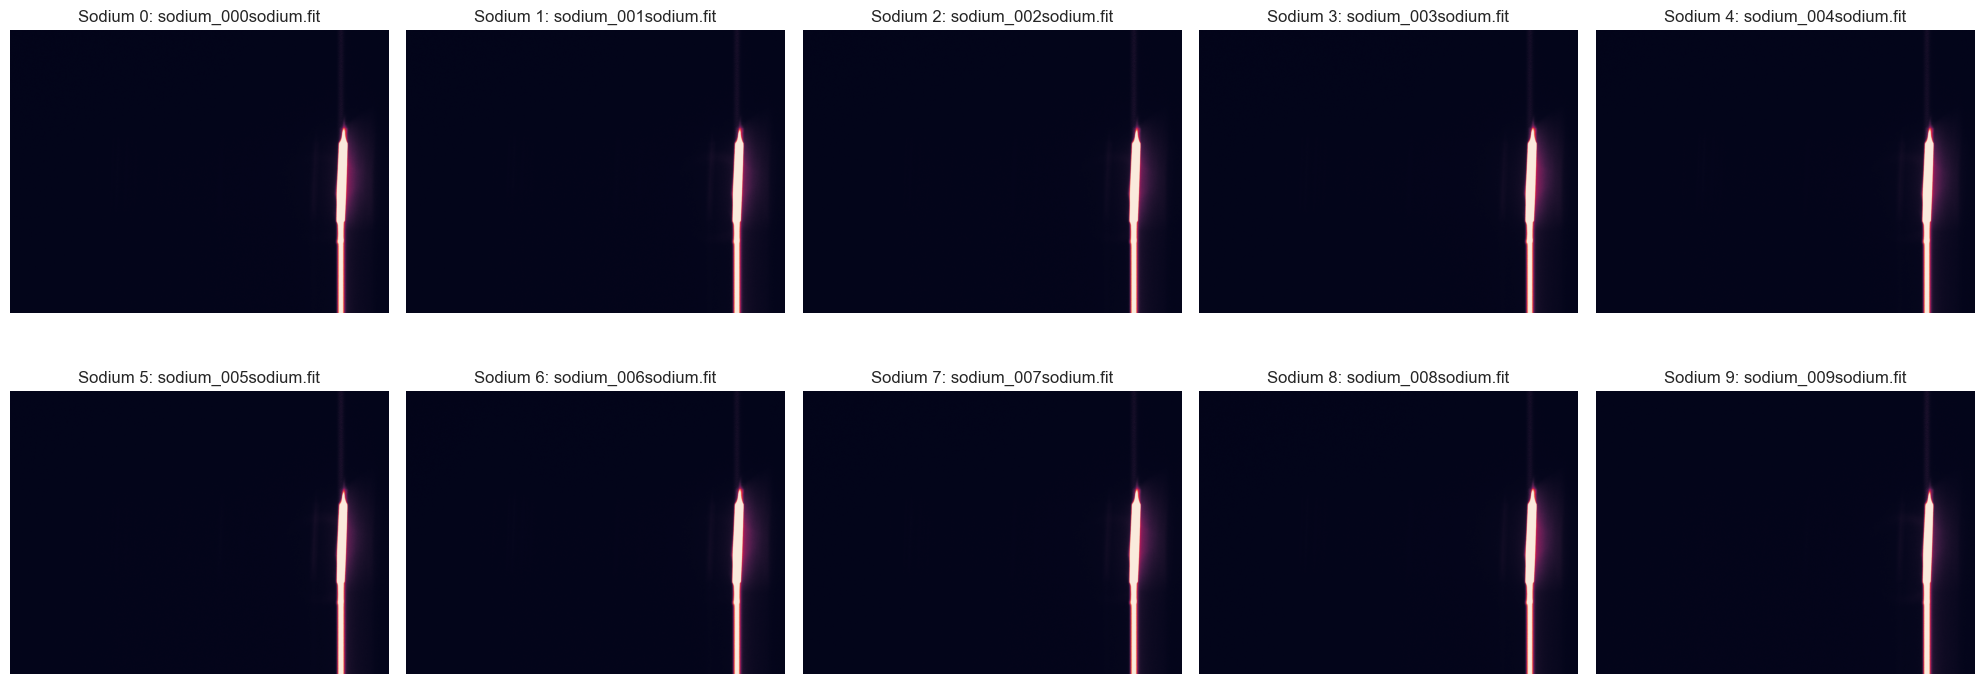

In [369]:
plot_image_grid(sodium, title_prefix="Sodium")

In [370]:
for i in range(len(sodium)):
    print(f"Image {i}\nmin: {np.min(fits.getdata(sodium[i]))}, max: {np.max(fits.getdata(sodium[i]))}")

Image 0
min: 193, max: 65535
Image 1
min: 193, max: 60921
Image 2
min: 189, max: 59868
Image 3
min: 193, max: 65535
Image 4
min: 186, max: 65535
Image 5
min: 190, max: 49077
Image 6
min: 201, max: 65535
Image 7
min: 191, max: 65535
Image 8
min: 187, max: 65535
Image 9
min: 189, max: 42236


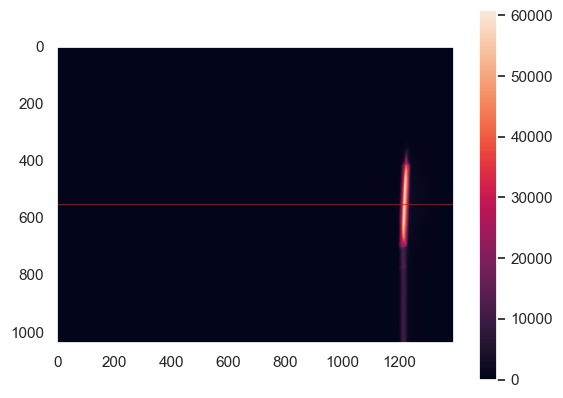

(1039, 1391)


In [371]:
# Chose image 1 as the best exposure

images = fits.open('sodium_001sodium.fit')
sod = images[0].data

plt.imshow(sod, vmin=0, vmax=60921)
plt.axhline(y=550, color='red', linewidth=0.5)
plt.colorbar()
plt.grid(False)

plt.show()

print(sod.shape)

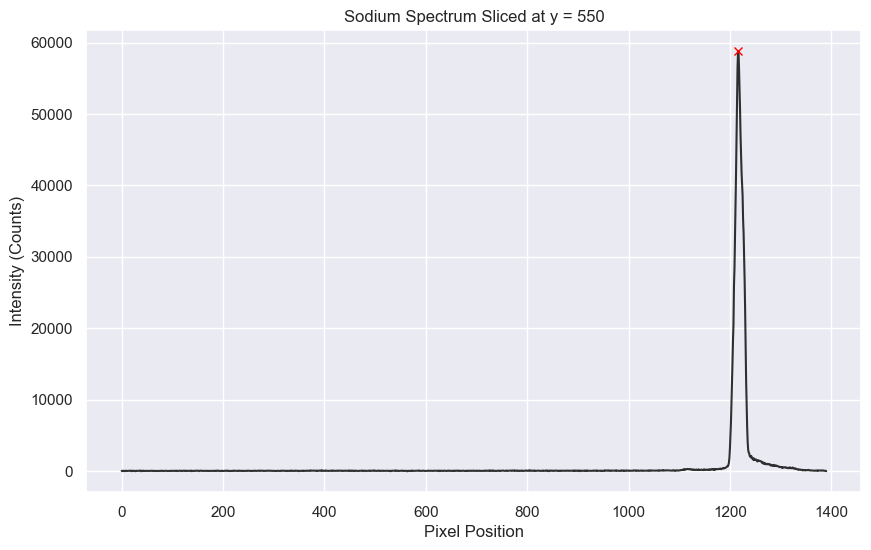

Peak X-positions (pixels): [1216]
Peak 1: x = 1216, Intensity = 58800.4


In [372]:
clean_sod = sod - master_bias

spec_slice_s = clean_sod[550, :]
peaks, properties = find_peaks(spec_slice_s, prominence=500, distance=10)

plt.figure(figsize=(10, 6))
plt.plot(spec_slice_s, color='black', alpha=0.8)
plt.plot(peaks, spec_slice_s[peaks], "x", color='red')

plt.title("Sodium Spectrum Sliced at y = 550")
plt.xlabel("Pixel Position")
plt.ylabel("Intensity (Counts)")

plt.show()

print(f"Peak X-positions (pixels): {peaks}")
for i, p in enumerate(peaks):
    print(f"Peak {i+1}: x = {p}, Intensity = {spec_slice_s[p]:.1f}")

In [373]:
m = 0.2071
c = 333.6445

def wavelenght_cali(px):
    return m * px + c

print(wavelenght_cali(1216))

# known sodium D-line at 589.3 nm
deviation = np.abs(wavelenght_cali(1216) - 589.3)
print(f'Sodium Deviation: {deviation} nm')

if deviation <= merc_err:
    print("The sodium measurement is within the margin of error of the mercury calibration.")
else:
    print("The sodium measurement is outside the margin of error.")

585.4781
Sodium Deviation: 3.821899999999914 nm
The sodium measurement is outside the margin of error.


### Sodium: Saturated (for discussion)

In [374]:
imagess = fits.open('sodium_004sodium-saturated.fit')
imagess[0].data
print(np.min(imagess[0].data), np.max(imagess[0].data))

222 65535


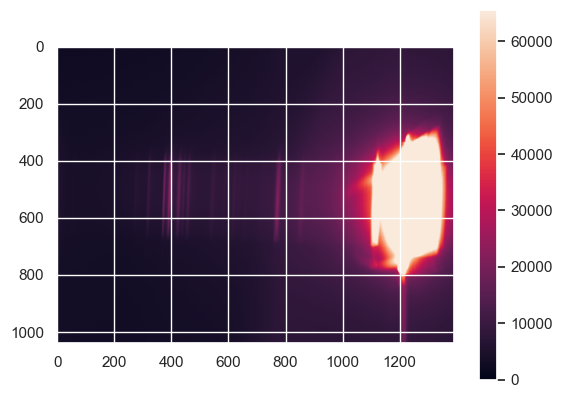

In [375]:
sodsat = imagess[0].data
plt.imshow(sodsat, vmin=0 ,vmax=65535)
plt.colorbar()

In [376]:
sodium_sat = sorted(glob('*sodium-saturated*'))
print(sodium_sat)

['sodium_000sodium-saturated.fit', 'sodium_001sodium-saturated.fit', 'sodium_002sodium-saturated.fit', 'sodium_003sodium-saturated.fit', 'sodium_004sodium-saturated.fit', 'sodium_005sodium-saturated.fit', 'sodium_006sodium-saturated.fit', 'sodium_007sodium-saturated.fit', 'sodium_008sodium-saturated.fit', 'sodium_009sodium-saturated.fit']


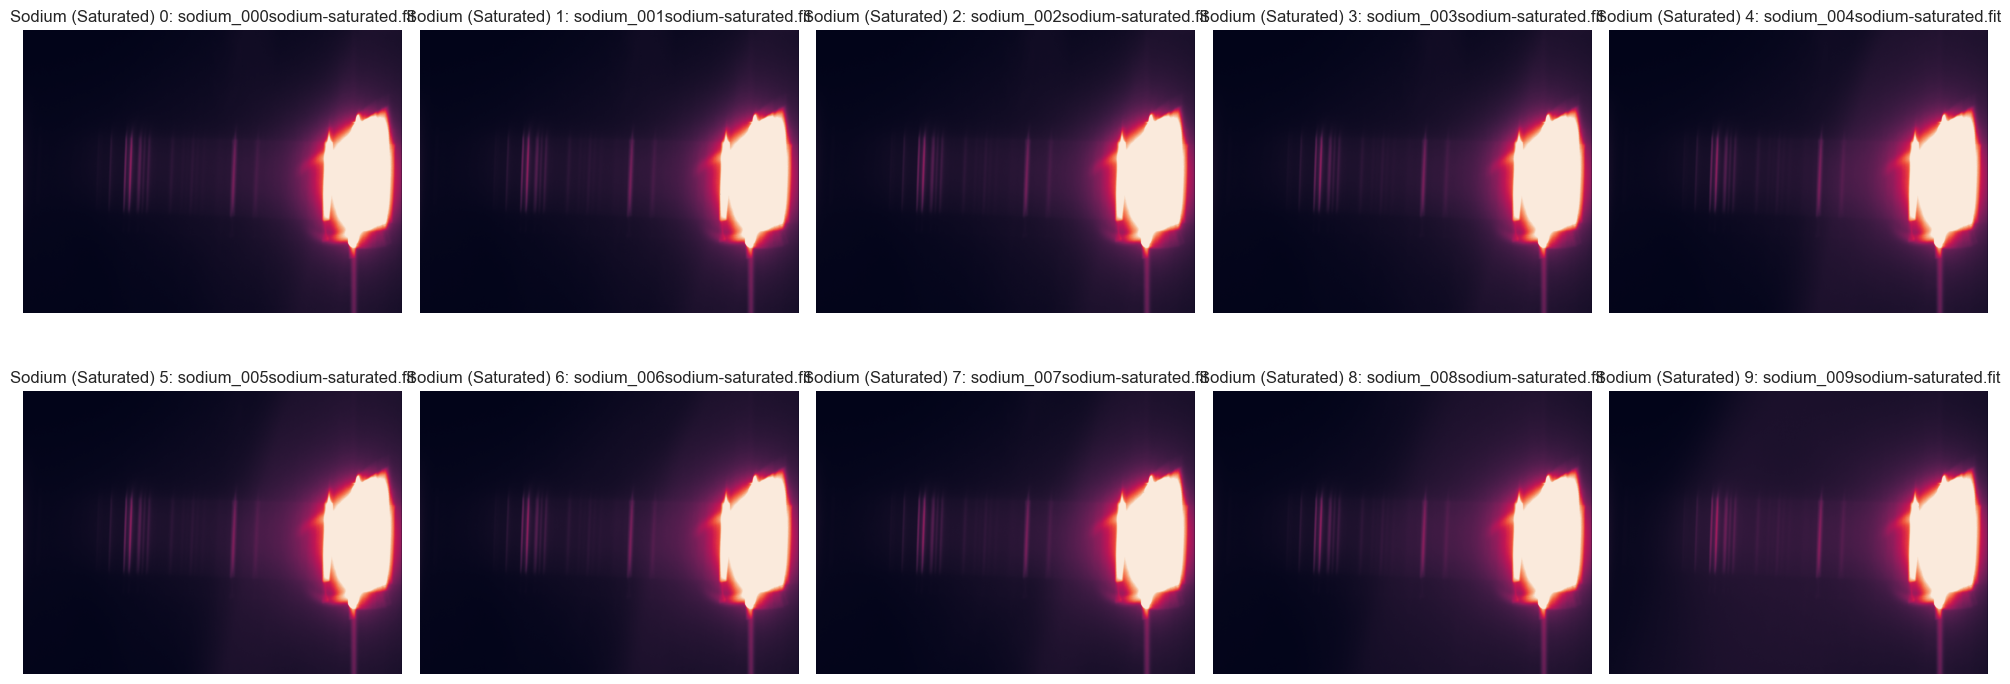

In [377]:
plot_image_grid(sodium_sat, title_prefix="Sodium (Saturated)")

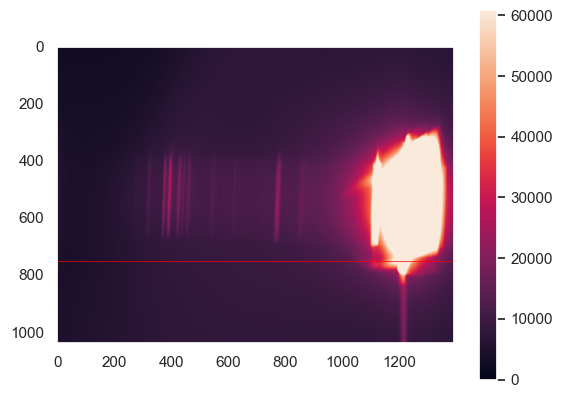

(1039, 1391)


In [378]:
# Chose image 9 as the best exposure

imagess = fits.open('sodium_009sodium-saturated.fit')
sodsat = imagess[0].data

plt.imshow(sodsat, vmin=0, vmax=60921)
plt.axhline(y=750, color='red', linewidth=0.5)
plt.colorbar()
plt.grid(False)

plt.show()

print(sodsat.shape)

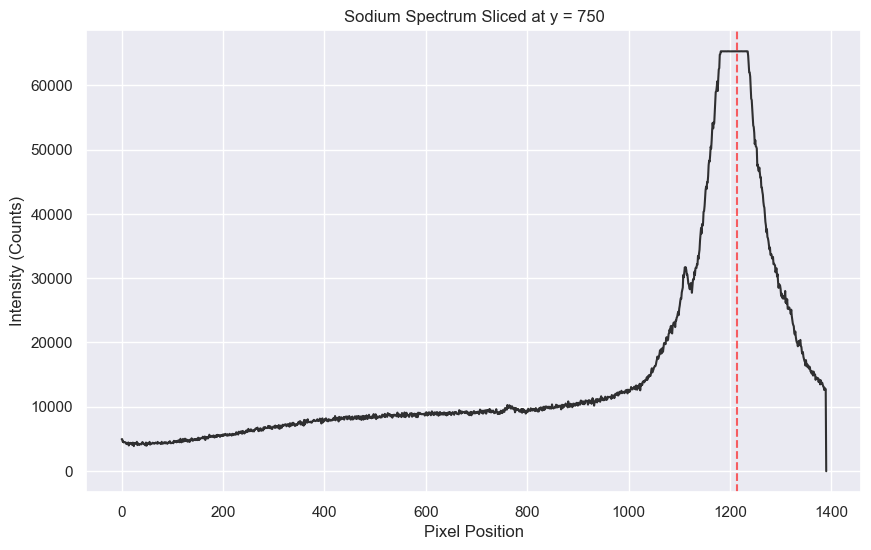

In [379]:
imagess = fits.open('sodium_009sodium-saturated.fit')
sodsat = imagess[0].data

clean_sod_sat = sodsat - master_bias

plt.figure(figsize=(10, 6))
plt.plot(clean_sod_sat[750, :], color='black', alpha=0.8)
plt.axvline(x=1213, color='red', linestyle='--', alpha=0.6)

plt.title("Sodium Spectrum Sliced at y = 750")
plt.xlabel("Pixel Position")
plt.ylabel("Intensity (Counts)")

plt.show()

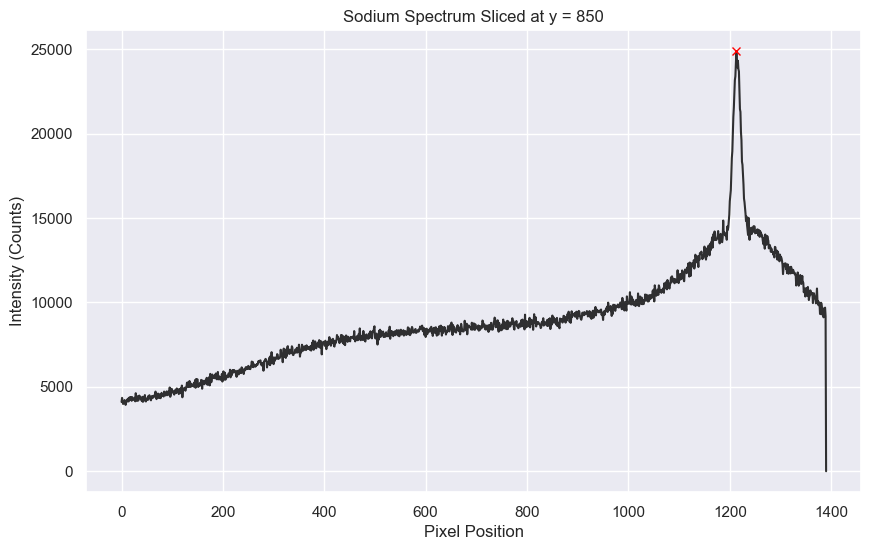

Peak X-positions (pixels): [1213]
Peak 1: x = 1213, Intensity = 24895.2


In [380]:
spec_slice_ss = clean_sod_sat[850, :]
peaks, properties = find_peaks(spec_slice_ss, prominence=1500, distance=10)

plt.figure(figsize=(10, 6))
plt.plot(spec_slice_ss, color='black', alpha=0.8)
plt.plot(peaks, spec_slice_ss[peaks], "x", color='red')

plt.title("Sodium Spectrum Sliced at y = 850")
plt.xlabel("Pixel Position")
plt.ylabel("Intensity (Counts)")

plt.show()

print(f"Peak X-positions (pixels): {peaks}")
for i, p in enumerate(peaks):
    print(f"Peak {i+1}: x = {p}, Intensity = {spec_slice_ss[p]:.1f}")

# Resolution (Gaussian)

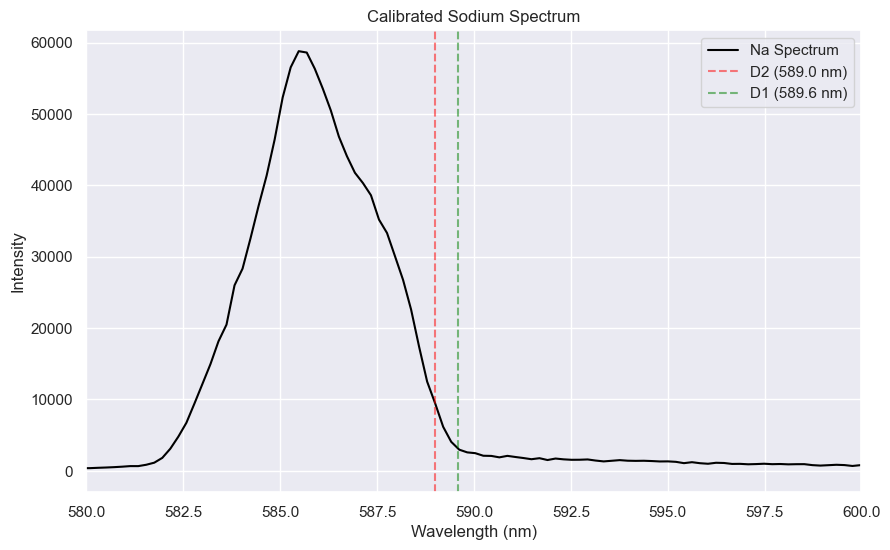

In [381]:
wavelengths = m * np.arange(len(spec_slice_s)) + c

plt.figure(figsize=(10, 6))
plt.plot(wavelengths, spec_slice_s, color='black', label='Na Spectrum')

plt.axvline(x=589.0, color='red', linestyle='--', alpha=0.5, label='D2 (589.0 nm)')
plt.axvline(x=589.6, color='green', linestyle='--', alpha=0.5, label='D1 (589.6 nm)')

plt.title("Calibrated Sodium Spectrum")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensity")
plt.xlim(580, 600)
plt.legend()

plt.show()

In [382]:
def gaussian(x, a, x0, sigma, offset):
    return a * np.exp(-(x - x0)**2 / (2 * sigma**2)) + offset

# For the 546 nm peak (Pixel 1026)
window = 15 # pixels around the peak
x_data = wavelengths[1026 - window : 1026 + window]
y_data = spec_slice_m[1026 - window : 1026 + window]

# initial guess for amplitude, mean, sigma, offset
popt, pcov = curve_fit(gaussian, x_data, y_data, p0=[max(y_data), 546, 1, min(y_data)])
errors = np.sqrt(np.diag(pcov))

err_amplitude = errors[0] # popt[0]: amplitude
err_center = errors[1] # popt[1]: centre
err_sigma = errors[2] # popt[2]: sigma/width
err_offset = errors[3] # popt[3]: offset

print(f"Fitted Center: {popt[1]:.4f} ± {err_center:.4f} nm")
print(f"Fitted Width: {popt[2]:.4f} ± {err_sigma:.4f} nm")

sigma = popt[2]
fwhm = 2.355 * abs(sigma)  # convert sigma to FWHM 
resolution = 546.0 / fwhm

err_fwhm = 2.355 * err_sigma
err_R = resolution * np.sqrt((err_fwhm / fwhm)**2 + (err_center / popt[1])**2)

print(f"FWHM (Δλ): {fwhm:.3f} ± {err_fwhm:.3f} nm")
print(f"Spectral Resolution (R): {resolution:.1f} ± {err_R:.1f}")

Fitted Center: 546.2202 ± 0.0339 nm
Fitted Width: 1.0489 ± 0.0571 nm
FWHM (Δλ): 2.470 ± 0.135 nm
Spectral Resolution (R): 221.0 ± 12.0


In [383]:
# For the 436 nm peak (Pixel 490)
window = 15 # pixels around the peak
x_data = wavelengths[490 - window : 490 + window]
y_data = spec_slice_m[490 - window : 490 + window]

# initial guess for amplitude, mean, sigma, offset
popt, pcov = curve_fit(gaussian, x_data, y_data, p0=[max(y_data), 436, 1, min(y_data)])
errors = np.sqrt(np.diag(pcov))

err_amplitude = errors[0] # popt[0]: amplitude
err_center = errors[1] # popt[1]: centre
err_sigma = errors[2] # popt[2]: sigma/width
err_offset = errors[3] # popt[3]: offset

print(f"Fitted Center: {popt[1]:.4f} ± {err_center:.4f} nm")
print(f"Fitted Width: {popt[2]:.4f} ± {err_sigma:.4f} nm")

sigma = popt[2]
fwhm = 2.355 * abs(sigma)  # convert sigma to FWHM 
resolution = 436.0 / fwhm

err_fwhm = 2.355 * err_sigma
err_R = resolution * np.sqrt((err_fwhm / fwhm)**2 + (err_center / popt[1])**2)

print(f"FWHM (Δλ): {fwhm:.3f} ± {err_fwhm:.3f} nm")
print(f"Spectral Resolution (R): {resolution:.1f} ± {err_R:.1f}")

Fitted Center: 435.1193 ± 0.0204 nm
Fitted Width: 0.6254 ± 0.0240 nm
FWHM (Δλ): 1.473 ± 0.056 nm
Spectral Resolution (R): 296.0 ± 11.3


In [384]:
# For the 405 nm peak (Pixel 341)
window = 15 # pixels around the peak
x_data = wavelengths[341 - window : 341 + window]
y_data = spec_slice_m[341 - window : 341 + window]

# initial guess for amplitude, mean, sigma, offset
popt, pcov = curve_fit(gaussian, x_data, y_data, p0=[max(y_data), 405, 1, min(y_data)])
errors = np.sqrt(np.diag(pcov))

err_amplitude = errors[0] # popt[0]: amplitude
err_center = errors[1] # popt[1]: centre
err_sigma = errors[2] # popt[2]: sigma/width
err_offset = errors[3] # popt[3]: offset

print(f"Fitted Center: {popt[1]:.4f} ± {err_center:.4f} nm")
print(f"Fitted Width: {popt[2]:.4f} ± {err_sigma:.4f} nm")

sigma = popt[2]
fwhm = 2.355 * abs(sigma)  # convert sigma to FWHM 
resolution = 405.0 / fwhm

err_fwhm = 2.355 * err_sigma
err_R = resolution * np.sqrt((err_fwhm / fwhm)**2 + (err_center / popt[1])**2)

print(f"FWHM (Δλ): {fwhm:.3f} ± {err_fwhm:.3f} nm")
print(f"Spectral Resolution (R): {resolution:.1f} ± {err_R:.1f}")

Fitted Center: 404.2695 ± 0.0486 nm
Fitted Width: 0.5909 ± 0.0562 nm
FWHM (Δλ): 1.391 ± 0.132 nm
Spectral Resolution (R): 291.1 ± 27.7


In [385]:
# For the 579 nm peak (Pixel 1186)
window = 15 # pixels around the peak
x_data = wavelengths[1186 - window : 1186 + window]
y_data = spec_slice_m[1186 - window : 1186 + window]

# initial guess for amplitude, mean, sigma, offset
popt, pcov = curve_fit(gaussian, x_data, y_data, p0=[max(y_data), 579, 1, min(y_data)])
errors = np.sqrt(np.diag(pcov))

err_amplitude = errors[0] # popt[0]: amplitude
err_center = errors[1] # popt[1]: centre
err_sigma = errors[2] # popt[2]: sigma/width
err_offset = errors[3] # popt[3]: offset

print(f"Fitted Center: {popt[1]:.4f} ± {err_center:.4f} nm")
print(f"Fitted Width: {popt[2]:.4f} ± {err_sigma:.4f} nm")

sigma = popt[2]
fwhm = 2.355 * abs(sigma)  # convert sigma to FWHM 
resolution = 579.0 / fwhm

err_fwhm = 2.355 * err_sigma
err_R = resolution * np.sqrt((err_fwhm / fwhm)**2 + (err_center / popt[1])**2)

print(f"FWHM (Δλ): {fwhm:.3f} ± {err_fwhm:.3f} nm")
print(f"Spectral Resolution (R): {resolution:.1f} ± {err_R:.1f}")

Fitted Center: 578.2830 ± 0.1012 nm
Fitted Width: 2.1309 ± 0.4147 nm
FWHM (Δλ): 5.018 ± 0.977 nm
Spectral Resolution (R): 115.4 ± 22.5
